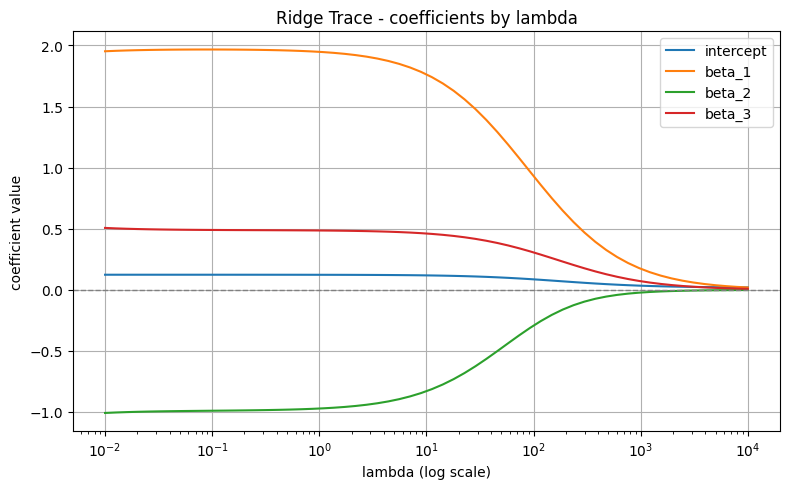

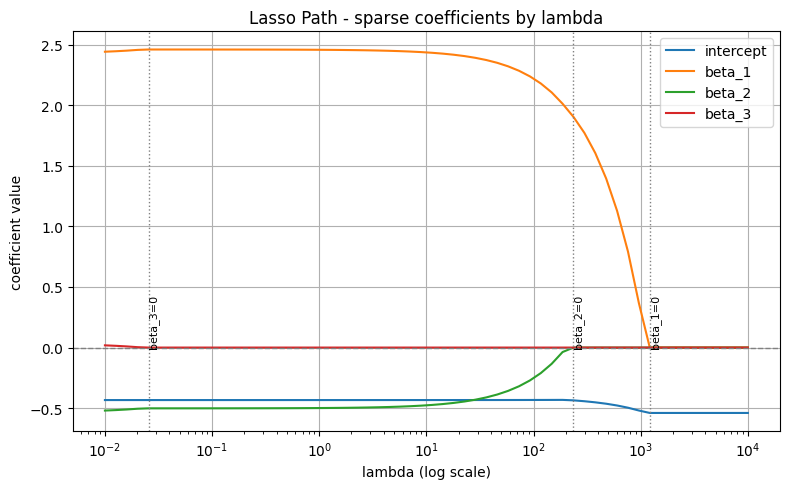

First lambda where coefficients become exactly zero:
  beta_1: 1215.47
  beta_2: 235.983
  beta_3: 0.0255141


In [1]:
from ridge_lasso import ridge_trace, lasso_trace, make_lambda_grid

# === Data mẫu: 3 features, x3 ≈ x1 + x2 (đa cộng tuyến) ===
import random
random.seed(42)

X = []
y = []
for _ in range(80):
    x1 = random.uniform(-10, 10)
    x2 = random.uniform(-10, 10)
    x3 = x1 + x2 + random.gauss(0, 0.01)  # gần phụ thuộc tuyến tính
    target = 2.0 * x1 - 1.0 * x2 + 0.5 * x3 + random.gauss(0, 1)
    X.append([x1, x2, x3])
    y.append(target)

# === Lambda grid chung ===
lambdas = make_lambda_grid(-2, 4, 60)

# === Ridge Trace ===
ridge_trace(X, y, lambda_grid=lambdas);

# === Lasso Trace ===
lasso_trace(X, y, lambda_grid=lambdas);


In [ ]:
import random
from part1.ridge_lasso import ridge_fit
from part1.residual_analysis import residual_diagnostics

# 1. Tạo dữ liệu giả lập (Synthetic Data)
random.seed(42)
n_samples = 100
X = []
y = []

# Mô hình thực tế: y = 5.0 + 2.5*x1 - 1.5*x2 + noise
for _ in range(n_samples):
    x1 = random.uniform(0, 10)
    x2 = random.uniform(0, 10)
    
    # Cố tình thêm noise dạng phân phối chuẩn (để Q-Q plot ra đường chéo đẹp)
    noise = random.gauss(mu=0, sigma=2.0)
    
    target = 5.0 + 2.5 * x1 - 1.5 * x2 + noise
    X.append([x1, x2])
    y.append(target)

# 2. Huấn luyện mô hình (dùng lam=0 tương đương OLS) để lấy y_hat
fit_result = ridge_fit(X, y, lam=0.0)
y_hat = fit_result["y_hat"]

# 3. Vẽ 4 biểu đồ chẩn đoán phần dư (nhớ thêm dấu ; để không in ra dict metrics)
fig, metrics = residual_diagnostics(y=y, y_hat=y_hat, X=X);
